<a href="https://colab.research.google.com/github/tisuama/LLM-Learning/blob/main/%E7%AC%AC%E4%B9%9D%E8%AC%9B%EF%BC%9A%E7%B0%A1%E5%96%AE%E7%A4%BA%E7%AF%84_Flow_Matching.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
torch.manual_seed(42)
np.random.seed(42)

## 定義源分佈 (source distribution) 和目標分佈 (target distribution)

In [ ]:
# 源分佈: 均值在原點，標準差為1的2D高斯
def sample_source_distribution(num_samples):
    """
    從源分佈採樣資料。
    假設源分佈是標準的2D高斯分佈。
    """
    return torch.randn(num_samples, 2) * 1.0 + torch.tensor([0.0, 0.0])

In [ ]:
sample_source_distribution(10)

tensor([[ 1.9269,  1.4873],
        [ 0.9007, -2.1055],
        [-0.7581,  1.0783],
        [ 0.8008,  1.6806],
        [ 0.3559, -0.6866],
        [-0.4934,  0.2415],
        [-0.2316,  0.0418],
        [-0.2516,  0.8599],
        [-0.3097, -0.3957],
        [ 0.8034, -0.6216]])

In [ ]:
# 目標分佈: 兩個2D高斯的混合
def sample_target_distribution(num_samples):
    """
    從目標分佈採樣資料。
    目標分佈是兩個2D高斯的混合。
    """
    # 定義每個高斯分佈的參數
    mean1 = torch.tensor([5.0, 5.0])
    std1 = 2.0
    weight1 = 0.3

    mean2 = torch.tensor([5.0, -5.0])
    std2 = 0.4
    weight2 = 0.7

    # 根據權重隨機選擇從哪個高斯分佈採樣
    choices = torch.multinomial(torch.tensor([weight1, weight2]), num_samples, replacement=True)

    samples = torch.zeros(num_samples, 2)

    # 從第一個高斯分佈採樣
    num_samples1 = (choices == 0).sum()
    samples[choices == 0] = torch.randn(num_samples1, 2) * std1 + mean1

    # 從第二個高斯分佈採樣
    num_samples2 = (choices == 1).sum()
    samples[choices == 1] = torch.randn(num_samples2, 2) * std2 + mean2

    return samples

In [ ]:
sample_target_distribution(10)

tensor([[ 5.0599, -5.0836],
        [ 4.8452, -4.6035],
        [ 4.9002,  6.0527],
        [ 5.1872, -5.0820],
        [ 4.7036, -4.8553],
        [ 5.7680, -5.0902],
        [ 4.9830,  6.4581],
        [ 5.2663,  6.7280],
        [ 4.8633, -4.8784],
        [ 2.9687,  3.2225]])

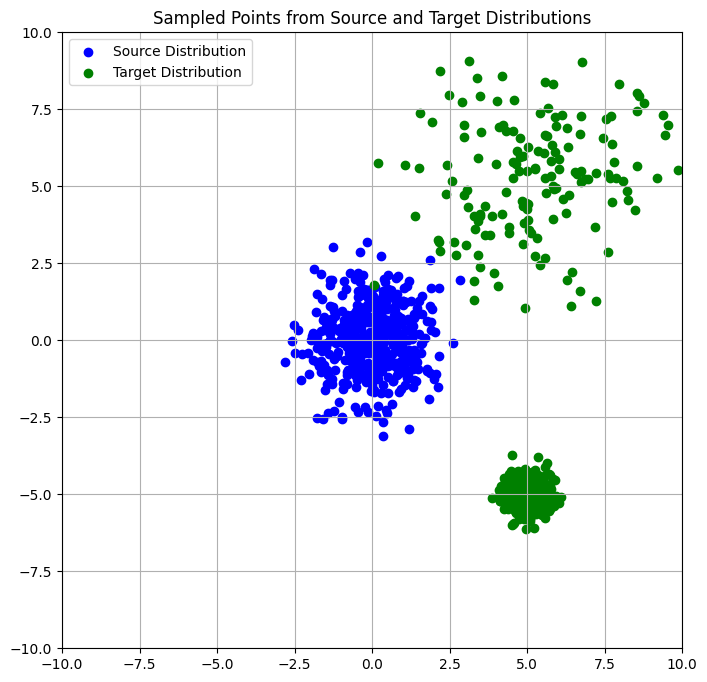

In [ ]:
# 畫圖看看源分佈和目標分佈分別長什麼樣子

# 從源分佈採樣
source_samples = sample_source_distribution(500)

# 從目標分佈採樣
target_samples = sample_target_distribution(500)

plt.figure(figsize=(8, 8))
plt.scatter(source_samples[:, 0], source_samples[:, 1], label='Source Distribution', color='blue')
plt.scatter(target_samples[:, 0], target_samples[:, 1], label='Target Distribution', color='green')
plt.title('Sampled Points from Source and Target Distributions')
plt.grid(True)
plt.xlim(-10, 10)
plt.ylim(-10, 10)
plt.legend()
plt.show()

## Flow Matching

#### 定義神經網路

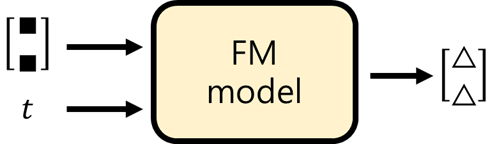

In [ ]:
# 這個網路將學習給定位置 x 和時間 t ，輸出要移動的方向
# 它接收一個3D向量作為輸入 (x 2D、t 1D)，輸出一個2D向量。
class FlowMatchingNet(nn.Module):
    def __init__(self):
        super().__init__()
        #此處的網路架構可以自由調整，只要輸入 3D ，輸出 2D 即可
        self.net = nn.Sequential(
            nn.Linear(3, 64), # 輸入是3D向量
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 2)  # 輸出是2D向量
        )

    def forward(self, input_data):
        return self.net(input_data)

### 定義如何製作訓練資料

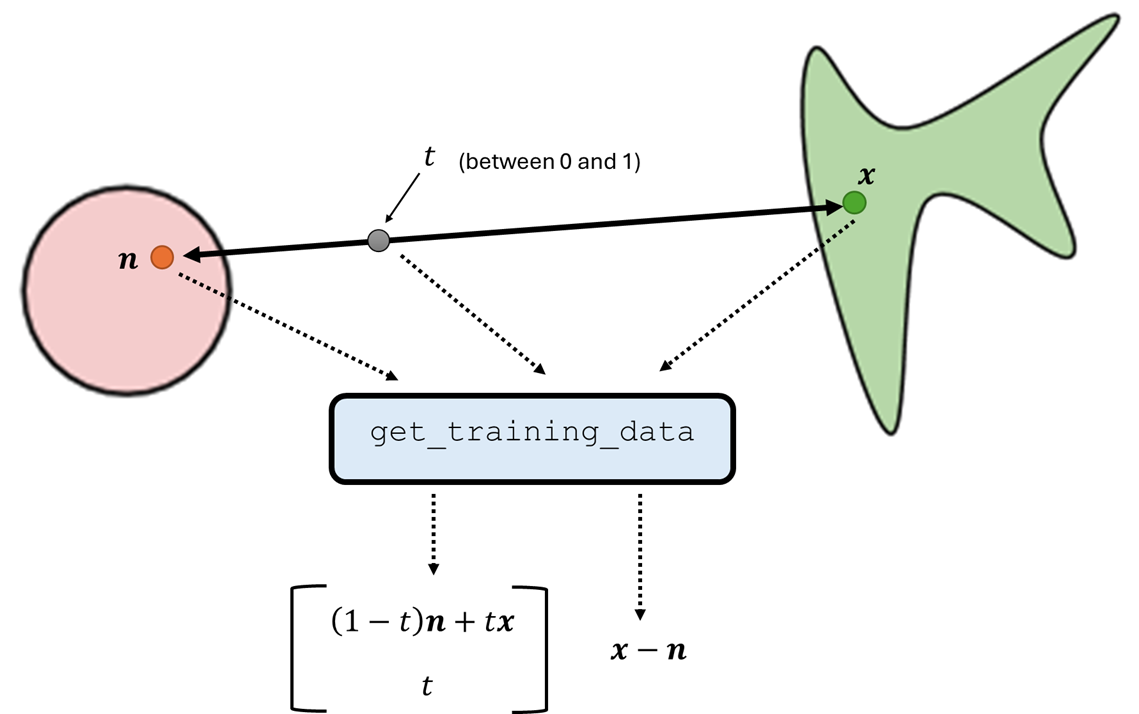

In [ ]:
# 給定從源分佈 sample 出來的 n 、從目標分佈 sample 出來的 x 、介於 0 到 1 之間的時間 t
# x_t = t * x + (1 - t) * n
# 我們的目標是訓練一個神經網路 f(x_t, t) 來預測 x - n
def get_training_data(n, x, t):
    x_t = (1 - t) * n + t * x
    label = x - n
    return torch.cat([x_t, t], dim=1), label

### 訓練開始

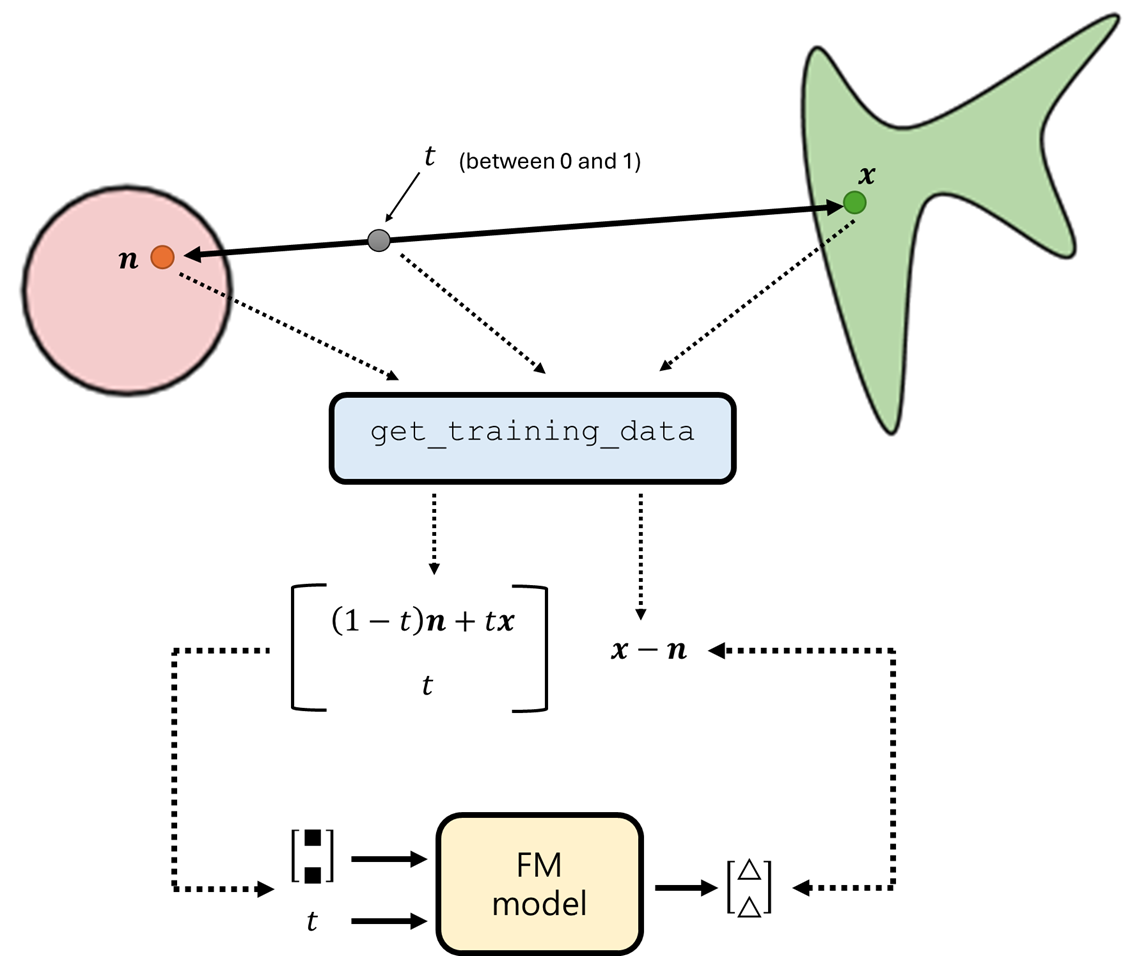

In [ ]:
model = FlowMatchingNet()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss() # 使用均方誤差作為損失函數
num_epochs = 1000 # 訓練輪數
batch_size = 256 # 批次大小

# --- 訓練迴圈 ---
print("開始訓練 FlowMatchingNet 模型...")
for epoch in range(num_epochs):

    # 從源分佈和目標分佈中採樣批次資料
    n_batch = sample_source_distribution(batch_size)
    x_batch = sample_target_distribution(batch_size)

    # 隨機採樣一個時間 t (介於 0 和 1 之間)
    t_batch = torch.rand(batch_size, 1)

    # 產生訓練資料
    input_data, label = get_training_data(n_batch, x_batch, t_batch)

    # 模型推論
    predicted = model(input_data)

    # 計算損失
    loss = criterion(predicted, label)

    # 反向傳播和優化
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

print("FlowMatchingNet 模型訓練完成！")

開始訓練 FlowMatchingNet 模型...
Epoch [100/1000], Loss: 6.2682
Epoch [200/1000], Loss: 4.8045
Epoch [300/1000], Loss: 4.8395
Epoch [400/1000], Loss: 4.8432
Epoch [500/1000], Loss: 3.9955
Epoch [600/1000], Loss: 3.3186
Epoch [700/1000], Loss: 3.7468
Epoch [800/1000], Loss: 3.5114
Epoch [900/1000], Loss: 4.5343
Epoch [1000/1000], Loss: 3.9006
FlowMatchingNet 模型訓練完成！


### 繪製生成過程

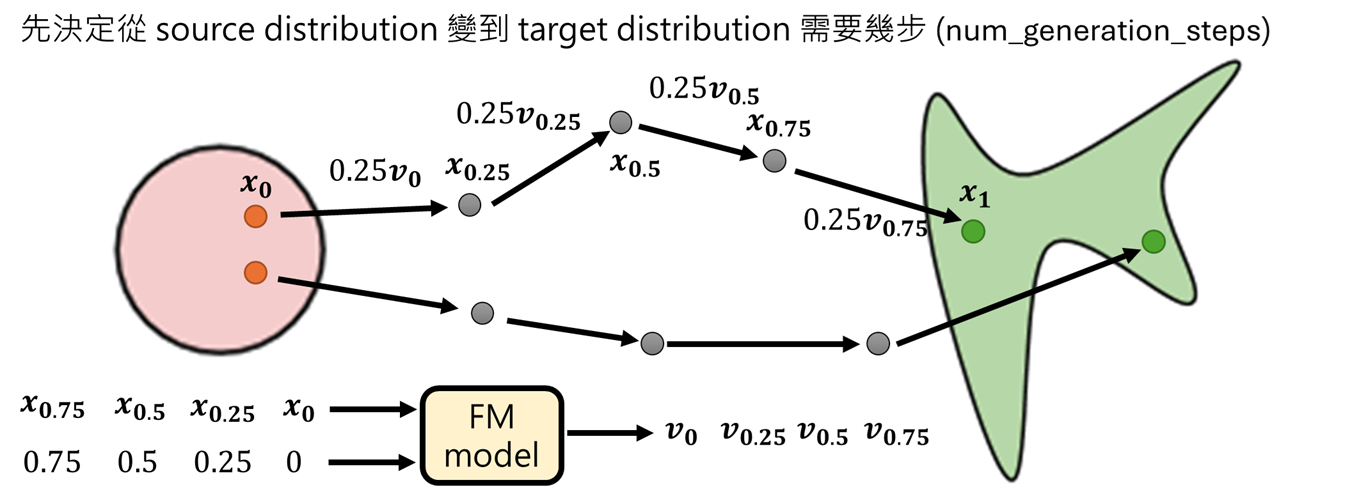


開始生成樣本並儲存軌跡...


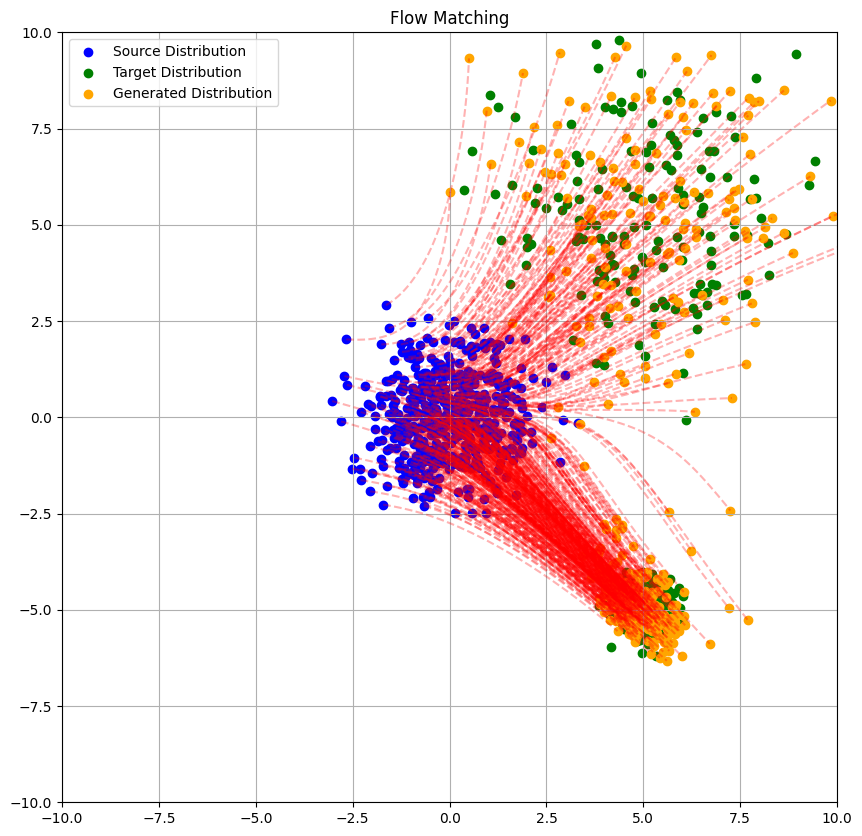

In [ ]:
# 訓練完成後，我們可以使用 FlowMatchingNet f(x, t) 來生成從源分佈到目標分佈的樣本。
# 這裡會需要多次迭代

num_generation_steps = 50 #要用幾步進行轉換？這是一個需要調整的超參數 (調調看會有甚麼影響)
initial_samples = sample_source_distribution(500) # 從源分佈採樣一些初始點

# 儲存每個時間步的樣本點，用於動畫或軌跡可視化
trajectories = [initial_samples.numpy()]
current_samples = initial_samples.clone()

dt = 1.0 / num_generation_steps # 每一步的時間增量

print("\n開始生成樣本並儲存軌跡...")
with torch.no_grad(): # 在推斷時不需要計算梯度
    for i in range(num_generation_steps):
        t = torch.tensor(i * dt) # 當前時間
        # 預測當前點 x 和時間 t 的向量場 t.unsqueeze(0).expand(x.shape[0], 1)
        predicted = model( torch.cat([current_samples, t.unsqueeze(0).expand(current_samples.shape[0], 1)], dim=1) )
        # 根據預測的速度更新點的位置
        current_samples = current_samples + predicted * dt
        trajectories.append(current_samples.numpy())

# 將軌跡轉換為 NumPy 陣列以便繪圖
trajectories = np.array(trajectories) # shape: (num_generation_steps + 1, num_samples, 2)

# 可視化結果
plt.figure(figsize=(10, 10))

# 繪製源分佈的樣本點
plt.scatter(initial_samples[:, 0].numpy(),
      initial_samples[:, 1].numpy(),
      label='Source Distribution', color='blue')

# 繪製目標分佈的樣本點
target_samples = sample_target_distribution(500)
plt.scatter(target_samples[:, 0].numpy(),
      target_samples[:, 1].numpy(),
      label='Target Distribution', color='green')

# 繪製生成的樣本點
plt.scatter(trajectories[-1, :, 0], trajectories[-1, :, 1],
           label='Generated Distribution', color='orange')

# 繪製生成的軌跡
for i in range(0, trajectories.shape[1]):
    plt.plot(trajectories[:, i, 0], trajectories[:, i, 1], alpha=0.3, color='red', linestyle='--')


plt.title('Flow Matching')
plt.legend()
plt.grid(True)
plt.xlim(-10, 10)
plt.ylim(-10, 10)
plt.show()

## 嘗試更難的目標分佈

In [ ]:
#定義另外一個目標分佈，這次是個螺紋
def sample_target2_distribution(num_samples):
    samples_per_spiral = num_samples // 2

    # Spiral 1
    s1 = torch.rand(samples_per_spiral) # s from 0 to 1
    r1 = s1 * 5.0
    angle1 = s1 * 3.0 * torch.pi

    x1 = r1 * torch.cos(angle1)
    y1 = r1 * torch.sin(angle1)

    # Add noise
    noise1_x = torch.randn(samples_per_spiral) * 0.1
    noise1_y = torch.randn(samples_per_spiral) * 0.1

    spiral1_samples = torch.stack([x1 + noise1_x, y1 + noise1_y], dim=1)

    # Spiral 2
    s2 = torch.rand(num_samples - samples_per_spiral) # s from 0 to 1
    r2 = s2 * 5.0
    angle2 = s2 * 3.0 * torch.pi + torch.pi # Offset by pi for the second spiral

    x2 = r2 * torch.cos(angle2)
    y2 = r2 * torch.sin(angle2)

    # Add noise
    noise2_x = torch.randn(num_samples - samples_per_spiral) * 0.1
    noise2_y = torch.randn(num_samples - samples_per_spiral) * 0.1

    spiral2_samples = torch.stack([x2 + noise2_x, y2 + noise2_y], dim=1)

    return torch.cat([spiral1_samples, spiral2_samples], dim=0)

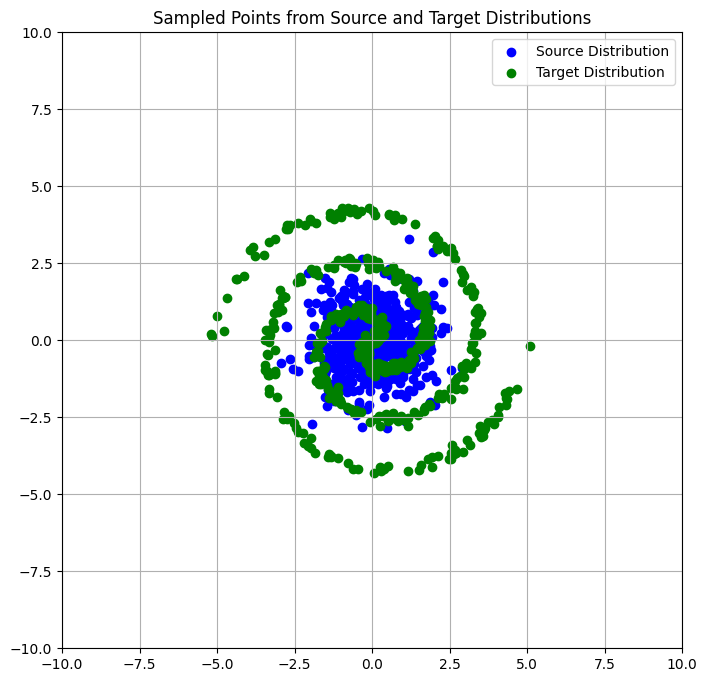

In [ ]:
# 畫圖看看源分佈和目標分佈分別長什麼樣子

# 從源分佈採樣
source_samples = sample_source_distribution(500)

# 從目標分佈採樣
target_samples = sample_target2_distribution(500)

plt.figure(figsize=(8, 8))
plt.scatter(source_samples[:, 0], source_samples[:, 1], label='Source Distribution', color='blue')
plt.scatter(target_samples[:, 0], target_samples[:, 1], label='Target Distribution', color='green')
plt.title('Sampled Points from Source and Target Distributions')
plt.grid(True)
plt.xlim(-10, 10)
plt.ylim(-10, 10)
plt.legend()
plt.show()

In [ ]:
model = FlowMatchingNet()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss() # 使用均方誤差作為損失函數
num_epochs = 1000 # 訓練輪數
batch_size = 256 # 批次大小

# --- 訓練迴圈 ---
print("開始訓練 FlowMatchingNet 模型...")
for epoch in range(num_epochs):

    # 從源分佈和目標分佈中採樣批次資料
    n_batch = sample_source_distribution(batch_size)
    x_batch = sample_target2_distribution(batch_size)

    # 隨機採樣一個時間 t (介於 0 和 1 之間)
    t_batch = torch.rand(batch_size, 1)

    # 產生訓練資料
    input_data, label = get_training_data(n_batch, x_batch, t_batch)

    # 模型推論
    predicted = model(input_data)

    # 計算損失
    loss = criterion(predicted, label)

    # 反向傳播和優化
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

print("FlowMatchingNet 模型訓練完成！")

開始訓練 FlowMatchingNet 模型...
Epoch [100/1000], Loss: 3.9185
Epoch [200/1000], Loss: 3.3001
Epoch [300/1000], Loss: 3.3155
Epoch [400/1000], Loss: 2.9999
Epoch [500/1000], Loss: 3.0783
Epoch [600/1000], Loss: 3.2902
Epoch [700/1000], Loss: 3.2455
Epoch [800/1000], Loss: 3.1444
Epoch [900/1000], Loss: 3.0971
Epoch [1000/1000], Loss: 3.1266
FlowMatchingNet 模型訓練完成！



開始生成樣本並儲存軌跡...


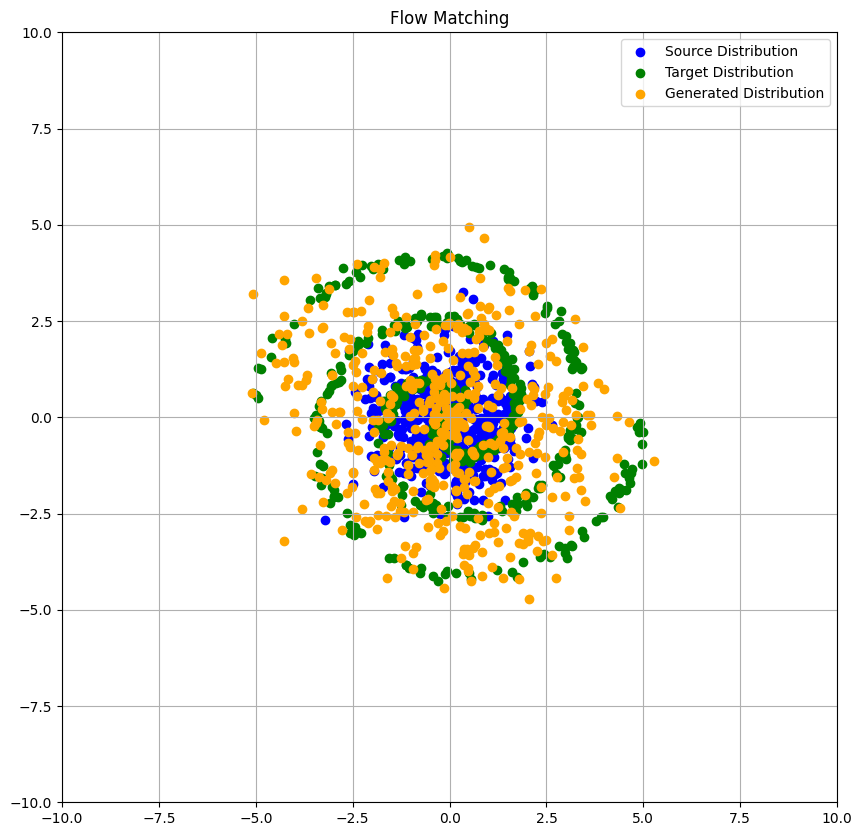

In [ ]:
# --- 繪製生成過程 ---
# 訓練完成後，我們可以使用 FlowMatchingNet f(x, t) 來生成從源分佈到目標分佈的樣本。
# 這裡會需要多次迭代

num_generation_steps = 50 #這是一個需要調整的超參數
initial_samples = sample_source_distribution(500) # 從源分佈採樣一些初始點

# 儲存每個時間步的樣本點，用於動畫或軌跡可視化
trajectories = [initial_samples.numpy()]
current_samples = initial_samples.clone()

dt = 1.0 / num_generation_steps # 每一步的時間增量

print("\n開始生成樣本並儲存軌跡...")
with torch.no_grad(): # 在推斷時不需要計算梯度
    for i in range(num_generation_steps):
        t = torch.tensor(i * dt) # 當前時間
        # 預測當前點 x 和時間 t 的向量場 t.unsqueeze(0).expand(x.shape[0], 1)
        predicted = model( torch.cat([current_samples, t.unsqueeze(0).expand(current_samples.shape[0], 1)], dim=1) )
        # 根據預測的速度更新點的位置
        current_samples = current_samples + predicted * dt
        trajectories.append(current_samples.numpy())

# 將軌跡轉換為 NumPy 陣列以便繪圖
trajectories = np.array(trajectories) # shape: (num_generation_steps + 1, num_samples, 2)

# 可視化結果
plt.figure(figsize=(10, 10))

# 繪製源分佈的樣本點
plt.scatter(initial_samples[:, 0].numpy(),
      initial_samples[:, 1].numpy(),
      label='Source Distribution', color='blue')

# 繪製目標分佈的樣本點
target_samples = sample_target2_distribution(500)
plt.scatter(target_samples[:, 0].numpy(),
      target_samples[:, 1].numpy(),
      label='Target Distribution', color='green')

# 繪製生成的樣本點
plt.scatter(trajectories[-1, :, 0], trajectories[-1, :, 1],
           label='Generated Distribution', color='orange')

plt.title('Flow Matching')
plt.legend()
plt.grid(True)
plt.xlim(-10, 10)
plt.ylim(-10, 10)
plt.show()

做不太起來，調超參數還是需要的．．．

In [ ]:
# --- 定義神經網路 ---
# 這個網路將學習給定位置 x 和時間 t ，輸出要移動的方向
# 它接收一個3D向量作為輸入 (x 2D、t 1D)，輸出一個2D向量。
class FlowMatchingNet(nn.Module):
    def __init__(self):
        super().__init__()
        #此處的網路架構可以自由調整，只要輸入 3D ，輸出 2D 即可
        self.net = nn.Sequential(
            nn.Linear(3, 256), # 輸入是3D向量
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 2)  # 輸出是2D向量
        )

    def forward(self, input_data):
        return self.net(input_data)

# --- 製作訓練資料 ---
# 給定從源分佈 sample 出來的 n 、從目標分佈 sample 出來的 x 、介於 0 到 1 之間的時間 t
# x_t = t * x + (1 - t) * n
# 我們的目標是訓練一個神經網路 f(x_t, t) 來預測 x - n
def get_training_data(n, x, t):
    x_t = t * x + (1 - t) * n
    label = x - n
    return torch.cat([x_t, t], dim=1), label

# --- 訓練設定 ---
model = FlowMatchingNet()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss() # 使用均方誤差作為損失函數
num_epochs = 5000 # 訓練輪數
batch_size = 256 # 批次大小

# --- 訓練迴圈 ---
print("開始訓練 FlowMatchingNet 模型...")
for epoch in range(num_epochs):

    # 從源分佈和目標分佈中採樣批次資料
    n_batch = sample_source_distribution(batch_size)
    x_batch = sample_target2_distribution(batch_size)

    # 隨機採樣一個時間 t (介於 0 和 1 之間)
    t_batch = torch.rand(batch_size, 1)

    # 產生訓練資料
    input_data, label = get_training_data(n_batch, x_batch, t_batch)

    # 模型推論
    predicted = model(input_data)

    # 計算損失
    loss = criterion(predicted, label)

    # 反向傳播和優化
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

print("FlowMatchingNet 模型訓練完成！")





開始訓練 FlowMatchingNet 模型...
Epoch [100/5000], Loss: 3.0852
Epoch [200/5000], Loss: 2.9672
Epoch [300/5000], Loss: 3.1171
Epoch [400/5000], Loss: 3.1991
Epoch [500/5000], Loss: 2.9974
Epoch [600/5000], Loss: 3.2368
Epoch [700/5000], Loss: 3.1015
Epoch [800/5000], Loss: 3.2068
Epoch [900/5000], Loss: 3.3487
Epoch [1000/5000], Loss: 2.9189
Epoch [1100/5000], Loss: 3.0135
Epoch [1200/5000], Loss: 3.5469
Epoch [1300/5000], Loss: 3.3446
Epoch [1400/5000], Loss: 3.1677
Epoch [1500/5000], Loss: 3.2730
Epoch [1600/5000], Loss: 3.2223
Epoch [1700/5000], Loss: 3.3171
Epoch [1800/5000], Loss: 3.2214
Epoch [1900/5000], Loss: 3.0195
Epoch [2000/5000], Loss: 3.4213
Epoch [2100/5000], Loss: 3.2969
Epoch [2200/5000], Loss: 2.9736
Epoch [2300/5000], Loss: 2.9183
Epoch [2400/5000], Loss: 3.3455
Epoch [2500/5000], Loss: 3.1282
Epoch [2600/5000], Loss: 2.8621
Epoch [2700/5000], Loss: 3.0778
Epoch [2800/5000], Loss: 3.3463
Epoch [2900/5000], Loss: 3.4899
Epoch [3000/5000], Loss: 3.3162
Epoch [3100/5000], Los


開始生成樣本並儲存軌跡...


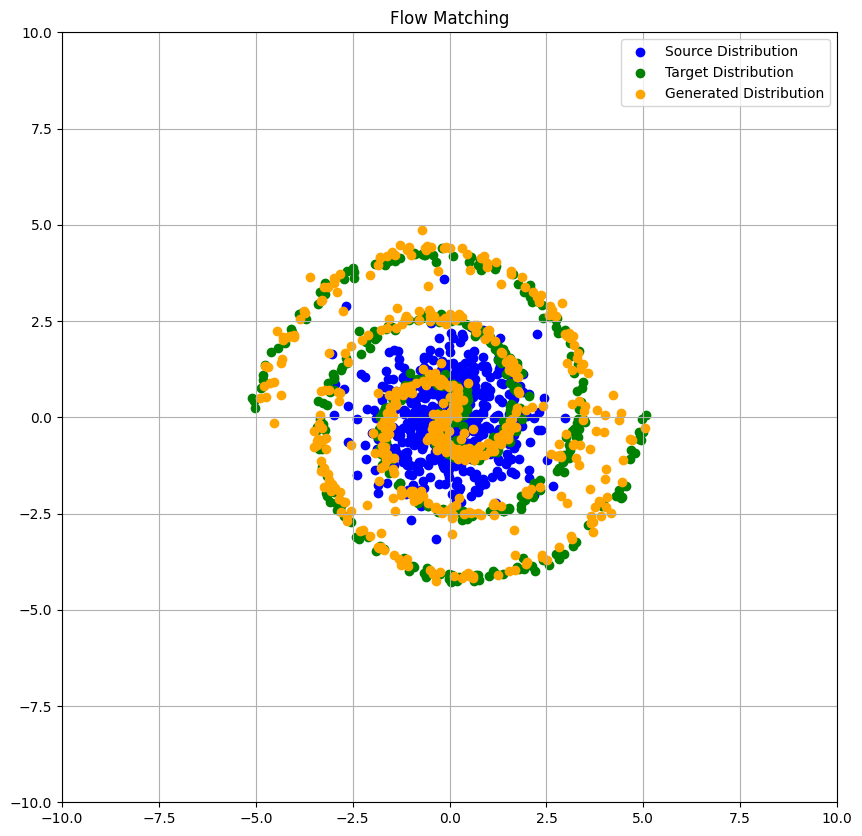

In [ ]:
# --- 繪製生成過程 ---
# 訓練完成後，我們可以使用 FlowMatchingNet f(x, t) 來生成從源分佈到目標分佈的樣本。
# 這裡會需要多次迭代

num_generation_steps = 50 #這是一個需要調整的超參數
initial_samples = sample_source_distribution(500) # 從源分佈採樣一些初始點

# 儲存每個時間步的樣本點，用於動畫或軌跡可視化
trajectories = [initial_samples.numpy()]
current_samples = initial_samples.clone()

dt = 1.0 / num_generation_steps # 每一步的時間增量

print("\n開始生成樣本並儲存軌跡...")
with torch.no_grad(): # 在推斷時不需要計算梯度
    for i in range(num_generation_steps):
        t = torch.tensor(i * dt) # 當前時間
        # 預測當前點 x 和時間 t 的向量場 t.unsqueeze(0).expand(x.shape[0], 1)
        predicted = model( torch.cat([current_samples, t.unsqueeze(0).expand(current_samples.shape[0], 1)], dim=1) )
        # 根據預測的速度更新點的位置
        current_samples = current_samples + predicted * dt
        trajectories.append(current_samples.numpy())

# 將軌跡轉換為 NumPy 陣列以便繪圖
trajectories = np.array(trajectories) # shape: (num_generation_steps + 1, num_samples, 2)

# 可視化結果
plt.figure(figsize=(10, 10))

# 繪製源分佈的樣本點
plt.scatter(initial_samples[:, 0].numpy(),
      initial_samples[:, 1].numpy(),
      label='Source Distribution', color='blue')

# 繪製目標分佈的樣本點
target_samples = sample_target2_distribution(500)
plt.scatter(target_samples[:, 0].numpy(),
      target_samples[:, 1].numpy(),
      label='Target Distribution', color='green')

# 繪製生成的樣本點
plt.scatter(trajectories[-1, :, 0], trajectories[-1, :, 1],
           label='Generated Distribution', color='orange')


plt.title('Flow Matching')
plt.legend()
plt.grid(True)
plt.xlim(-10, 10)
plt.ylim(-10, 10)
plt.show()

In [ ]:
import matplotlib.animation as animation
from IPython.display import HTML

# --- 創建動畫來展示 Flow Matching 的過程 ---

num_grid_points_per_dim = 20
x_min, x_max = -10, 10
y_min, y_max = -10, 10

plot_x = np.linspace(x_min, x_max, num_grid_points_per_dim)
plot_y = np.linspace(y_min, y_max, num_grid_points_per_dim)

grid_x, grid_y = np.meshgrid(plot_x, plot_y)

grid_points = torch.tensor(np.stack([grid_x.flatten(), grid_y.flatten()], axis=1), dtype=torch.float32)


fig, ax = plt.subplots(figsize=(8, 8))

def animate(i):
    ax.clear()
    # 繪製源分佈的樣本點 (固定)
    ax.scatter(initial_samples[:, 0].numpy(),
               initial_samples[:, 1].numpy(),
               label='Source Distribution', color='blue', alpha=0.3)

    # 繪製目標分佈的樣本點 (固定)
    ax.scatter(target_samples[:, 0].numpy(),
               target_samples[:, 1].numpy(),
               label='Target Distribution', color='green', alpha=0.3)

    # 繪製當前時間步的樣本點
    ax.scatter(trajectories[i, :, 0],
               trajectories[i, :, 1],
               label=f'Samples at t={i/num_generation_steps:.2f}', color='orange')

    # 畫出力場
    current_t = torch.tensor(i * dt, dtype=torch.float32).unsqueeze(0).expand(grid_points.shape[0], 1)
    model_input = torch.cat([grid_points, current_t], dim=1)
    with torch.no_grad():
        predicted_vector_field = model(model_input)
    vector_field_u = predicted_vector_field[:, 0].reshape(grid_x.shape)
    vector_field_v = predicted_vector_field[:, 1].reshape(grid_y.shape)
    ax.quiver(grid_x, grid_y, vector_field_u, vector_field_v, color='red', alpha=0.5, scale_units='xy', scale=10)

    ax.set_title('Flow Matching Animation')
    ax.set_xlim(-10, 10)
    ax.set_ylim(-10, 10)
    ax.grid(True)
    ax.legend(loc='upper left')
    return fig,

ani = animation.FuncAnimation(fig, animate, frames=len(trajectories), interval=150, blit=True)

plt.close(fig)

# 將動畫嵌入到Notebook中
HTML(ani.to_jshtml())